In [1]:
# 0. 安裝與匯入
!pip install -q xlrd

import os
import warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings("ignore")
print("✅ 環境完成")

# 1. 全域設定
BASE_PATH = '/content/drive/My Drive/'
FOLDER_ABNORMAL = '掉血壓名單'      # 原始資料夾標籤 = 1
FOLDER_NORMAL = '不掉血壓名單'      # 原始資料夾標籤 = 0

abnormal_path = os.path.join(BASE_PATH, FOLDER_ABNORMAL)
normal_path = os.path.join(BASE_PATH, FOLDER_NORMAL)

# 主要模式：
# "folder" = 直接使用資料夾標籤（較適合作業版）
# "rule"   = 使用 session 規則式標籤（較適合研究版）
LABEL_MODE = "rule"

# session 切分與清洗
SESSION_GAP_HOURS = 6
MIN_LEN = 30
CORE_MISSING_RATIO = 0.6
MAX_LEN = 300
DROP_COL_THRESHOLD = 0.95

# 規則式標籤門檻（只有 LABEL_MODE='rule' 會用到）
RULE_BP_COL = 'MAX_BLOOD'
LOW_THRESHOLD = 90
DROP_THRESHOLD = 30
DBP_LOW_THRESHOLD = 50

# feature columns
PREFERRED_FEATURES = [
    'TOTAL_UF', 'BLOOD_FLOW', 'CONDUCTIVITY',
    'VENOUS', 'TEMP', 'MAX_BLOOD', 'MIN_BLOOD',
    'PULSE', 'TMP', 'UF', 'DIA_FLOW', 'TARGET_UF',
    'SYRINGE_FLOW_RATE', 'TIMES', 'MANUAL_INPUT',
    'HD_SOURCE', 'ALERT', 'BLOOD_FUN', 'BREATH'
]

# KNN 搜尋空間
PCA_SETTINGS = [0.7, 0.8, 0.9, 0.95, 10, 20, 30]
K_LIST = [1, 3, 5, 7, 9, 11, 15, 19]
WEIGHT_LIST = ['uniform', 'distance']

# 平衡 training set 的最低少數類樣本數
MIN_MINORITY_FOR_BALANCE = 30
print(f"✅ LABEL_MODE = {LABEL_MODE}")

Mounted at /content/drive
✅ 環境完成
✅ LABEL_MODE = rule


In [2]:
# 2. 讀檔與欄位判斷
def detect_time_column(df):
    for c in ['REC_DATE', 'DATA_TIME', 'UDATE']:
        if c in df.columns:
            return c
    return None

def read_single_xls(file_path, label, source_folder):
    try:
        df = pd.read_excel(file_path, engine='xlrd')
        return {
            'file_name': os.path.basename(file_path),
            'file_path': file_path,
            'label': label,
            'source_folder': source_folder,
            'data': df
        }
    except Exception as e:
        print(f"❌ 讀取失敗: {file_path}, error={e}")
        return None

def read_all_xls_in_folder(folder_path, label, source_folder):
    items = []
    if not os.path.exists(folder_path):
        print(f"❌ 找不到資料夾: {folder_path}")
        return items

    files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith('.xls')])
    print(f"\n📂 讀取資料夾: {os.path.basename(folder_path)}")
    print(f"   共找到 {len(files)} 個 xls 檔")

    for file in files:
        file_path = os.path.join(folder_path, file)
        result = read_single_xls(file_path, label, source_folder)
        if result is not None:
            print(f"   ✅ {file} -> shape={result['data'].shape}")
            items.append(result)
    return items

abnormal_files = read_all_xls_in_folder(abnormal_path, label=1, source_folder=FOLDER_ABNORMAL)
normal_files = read_all_xls_in_folder(normal_path, label=0, source_folder=FOLDER_NORMAL)
all_file_items = abnormal_files + normal_files

print("\n==============================")
print("✅ 全部檔案讀取完成")
print("總檔案數:", len(all_file_items))
print("掉血壓檔案數:", len(abnormal_files))
print("不掉血壓檔案數:", len(normal_files))
print("==============================")


📂 讀取資料夾: 掉血壓名單
   共找到 10 個 xls 檔
   ✅ 01.xls -> shape=(55907, 44)
   ✅ 02.xls -> shape=(56645, 44)
   ✅ 03.xls -> shape=(61514, 44)
   ✅ 04.xls -> shape=(50267, 44)
   ✅ 05.xls -> shape=(61503, 44)
   ✅ 06.xls -> shape=(61364, 44)
   ✅ 07.xls -> shape=(43617, 44)
   ✅ 08.xls -> shape=(60699, 44)
   ✅ 09.xls -> shape=(61703, 44)
   ✅ 10.xls -> shape=(24124, 44)

📂 讀取資料夾: 不掉血壓名單
   共找到 10 個 xls 檔
   ✅ 01.xls -> shape=(47194, 44)
   ✅ 02.xls -> shape=(38649, 44)
   ✅ 03.xls -> shape=(61140, 44)
   ✅ 04.xls -> shape=(31280, 44)
   ✅ 05.xls -> shape=(28673, 44)
   ✅ 06.xls -> shape=(55769, 44)
   ✅ 07.xls -> shape=(30693, 44)
   ✅ 08.xls -> shape=(49892, 44)
   ✅ 09.xls -> shape=(56406, 44)
   ✅ 10.xls -> shape=(52975, 44)

✅ 全部檔案讀取完成
總檔案數: 20
掉血壓檔案數: 10
不掉血壓檔案數: 10


In [3]:
# 3. 第一次掃描：建立 usable_file_items 與統一欄位
all_feature_columns = set()
usable_file_items = []

for item in all_file_items:
    df_raw = item['data'].copy()
    time_col = detect_time_column(df_raw)

    if time_col is None or 'PAT_NO' not in df_raw.columns:
        print(f"⚠️ 略過 {item['file_name']}：缺少 PAT_NO 或時間欄位")
        continue

    df = df_raw.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    df = df.dropna(subset=['PAT_NO', time_col]).copy()

    if df.empty:
        print(f"⚠️ 略過 {item['file_name']}：有效資料為空")
        continue

    df['PAT_NO'] = df['PAT_NO'].astype(str)

    numeric_df = df.select_dtypes(include=[np.number]).copy()
    numeric_df = numeric_df.drop(columns=['PAT_NO'], errors='ignore')

    if numeric_df.shape[1] == 0:
        print(f"⚠️ 略過 {item['file_name']}：無數值欄位")
        continue

    missing_ratio = numeric_df.isna().mean()
    kept_cols = missing_ratio[missing_ratio <= DROP_COL_THRESHOLD].index.tolist()
    numeric_df = numeric_df[kept_cols].copy()

    if len(numeric_df.columns) == 0:
        print(f"⚠️ 略過 {item['file_name']}：刪除高缺失欄位後無特徵")
        continue

    file_feature_cols = [c for c in PREFERRED_FEATURES if c in numeric_df.columns]
    if len(file_feature_cols) < 5:
        file_feature_cols = numeric_df.columns.tolist()

    all_feature_columns.update(file_feature_cols)

    usable_file_items.append({
        'file_name': item['file_name'],
        'file_path': item['file_path'],
        'label': item['label'],
        'source_folder': item['source_folder'],
        'time_col': time_col,
        'data': df
    })

all_feature_columns = sorted(list(all_feature_columns))

print("\n📌 統一後特徵數:", len(all_feature_columns))
print("📌 特徵欄位:", all_feature_columns)
print("📌 可用檔案數:", len(usable_file_items))


📌 統一後特徵數: 19
📌 特徵欄位: ['ALERT', 'BLOOD_FLOW', 'BLOOD_FUN', 'BREATH', 'CONDUCTIVITY', 'DIA_FLOW', 'HD_SOURCE', 'MANUAL_INPUT', 'MAX_BLOOD', 'MIN_BLOOD', 'PULSE', 'SYRINGE_FLOW_RATE', 'TARGET_UF', 'TEMP', 'TIMES', 'TMP', 'TOTAL_UF', 'UF', 'VENOUS']
📌 可用檔案數: 20


In [4]:
# 4. 第二次掃描：建立全域 median
value_pool = {col: [] for col in all_feature_columns}

for item in usable_file_items:
    df = item['data'].copy()
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    numeric_df = numeric_df.drop(columns=['PAT_NO'], errors='ignore')
    numeric_df = numeric_df.reindex(columns=all_feature_columns)

    for col in all_feature_columns:
        vals = pd.to_numeric(numeric_df[col], errors='coerce').dropna().values
        if len(vals) > 0:
            value_pool[col].extend(vals.tolist())

global_medians = {}
for col in all_feature_columns:
    global_medians[col] = float(np.median(value_pool[col])) if len(value_pool[col]) > 0 else 0.0

print("✅ 已建立 global_medians")

✅ 已建立 global_medians


In [5]:
# 5. session 切分 / 清洗 / 標籤 / 特徵
def assign_sessions(df_in, patient_col='PAT_NO',
                    time_col='REC_DATE',
                    gap_hours=6):
    df_in = df_in.copy()
    df_in = df_in.sort_values([patient_col, time_col]).reset_index(drop=True)

    session_ids = []
    current_session = 0
    prev_patient = None
    prev_time = None

    for _, row in df_in.iterrows():
        patient = row[patient_col]
        t = row[time_col]

        new_session = False
        if prev_patient is None:
            new_session = True
        elif patient != prev_patient:
            new_session = True
        else:
            delta_hours = (t - prev_time).total_seconds() / 3600.0
            if delta_hours > gap_hours:
                new_session = True

        if new_session:
            current_session += 1

        session_ids.append(f"S{current_session:05d}")
        prev_patient = patient
        prev_time = t

    df_in['SESSION_ID'] = session_ids
    return df_in

def clean_session_df(session_df, feature_cols, global_medians, min_len=30, core_missing_ratio=0.6):
    x = session_df[feature_cols].copy()

    row_valid_ratio = x.notna().mean(axis=1)
    x = x[row_valid_ratio >= core_missing_ratio].copy()

    if len(x) < min_len:
        return None

    x = x.interpolate(method='linear', limit_direction='both', axis=0)
    x = x.ffill().bfill()

    for col in feature_cols:
        if x[col].isna().all():
            x[col] = global_medians[col]
        else:
            x[col] = x[col].fillna(x[col].median())

    x = x.fillna(pd.Series(global_medians))
    return x

def rule_based_label(df_feat,
                     sbp_col='MAX_BLOOD',
                     dbp_col='MIN_BLOOD',
                     low_threshold=LOW_THRESHOLD,
                     drop_threshold=DROP_THRESHOLD,
                     dbp_low_threshold=DBP_LOW_THRESHOLD):
    """
    1 = abnormal
    0 = normal

    規則：
    A. 收縮壓最低值 < low_threshold
    B. 收縮壓相對起始 baseline 下降 >= drop_threshold
    C. 舒張壓最低值 < dbp_low_threshold

    判異常條件：
    (A and B) 或 (A and C)
    """

    if sbp_col not in df_feat.columns:
      return 0

    sbp = pd.to_numeric(df_feat[sbp_col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if len(sbp) < 5:
      return 0

    sbp = sbp.values.astype(float)

    # 用前5筆平均當 baseline，比第一筆穩
    baseline = np.mean(sbp[:5])
    sbp_min = np.min(sbp)
    sbp_drop = baseline - sbp_min

    rule_a = sbp_min < low_threshold
    rule_b = sbp_drop >= drop_threshold

    rule_c = False
    if dbp_col in df_feat.columns:
        dbp = pd.to_numeric(df_feat[dbp_col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
        if len(dbp) >= 5:
            dbp = dbp.values.astype(float)
            dbp_min = np.min(dbp)
            rule_c = dbp_min < dbp_low_threshold

    if (rule_a and rule_b) or (rule_a and rule_c):
        return 1
    return 0

def extract_stat_features(df_feat):
    diff = df_feat.diff().fillna(0)
    n = len(df_feat)
    s1 = df_feat.iloc[:max(1, n // 3)]
    s2 = df_feat.iloc[max(1, n // 3):max(2, 2 * n // 3)]
    s3 = df_feat.iloc[max(2, 2 * n // 3):]

    slopes = []
    x_idx = np.arange(len(df_feat))
    for col in df_feat.columns:
        vals = pd.to_numeric(df_feat[col], errors='coerce').ffill().bfill().fillna(0).values
        if len(vals) >= 2 and np.std(vals) > 1e-8:
            m = np.polyfit(x_idx, vals, 1)[0]
        else:
            m = 0.0
        slopes.append(m)

    bp_special = []
    bp_col = 'MIN_BLOOD' if 'MIN_BLOOD' in df_feat.columns else None
    if bp_col is not None:
        vals = pd.to_numeric(df_feat[bp_col], errors='coerce').ffill().bfill().fillna(0).values
        if len(vals) > 0:
            bp_special.extend([
                np.min(vals),
                np.max(vals),
                vals[-1] - vals[0],
                vals[0] - np.min(vals),
                np.argmin(vals) / max(len(vals)-1, 1)
            ])
        else:
            bp_special.extend([0, 0, 0, 0, 0])
    else:
        bp_special.extend([0, 0, 0, 0, 0])

    feats = np.concatenate([
        df_feat.mean().values,
        df_feat.std(ddof=0).values,
        df_feat.min().values,
        df_feat.max().values,
        df_feat.median().values,
        df_feat.quantile(0.25).values,
        df_feat.quantile(0.75).values,
        (df_feat.max() - df_feat.min()).values,
        df_feat.iloc[0].values,
        df_feat.iloc[-1].values,
        (df_feat.iloc[-1] - df_feat.iloc[0]).values,
        diff.abs().mean().values,
        diff.abs().std(ddof=0).values,
        s1.mean().values,
        s2.mean().values,
        s3.mean().values,
        np.array(slopes, dtype=np.float32),
        np.array(bp_special, dtype=np.float32)
    ]).astype(np.float32)

    return feats

In [6]:
# 6. 建立 session 樣本
sequences = []
labels = []
stats_features = []
session_meta = []

total_candidate_sessions = 0
kept_sessions = 0
skipped_sessions = 0

for item in usable_file_items:
    file_name = item['file_name']
    source_folder = item['source_folder']
    original_file_label = item['label']
    time_col = item['time_col']
    df = item['data'].copy()

    df = df.sort_values(['PAT_NO', time_col]).reset_index(drop=True)

    numeric_df = df.select_dtypes(include=[np.number]).copy()
    numeric_df = numeric_df.drop(columns=['PAT_NO'], errors='ignore')
    numeric_df = numeric_df.reindex(columns=all_feature_columns)

    df_model = pd.concat(
        [
            df[['PAT_NO', time_col]].reset_index(drop=True),
            numeric_df.reset_index(drop=True)
        ],
        axis=1
    )

    df_model = assign_sessions(
        df_model,
        patient_col='PAT_NO',
        time_col=time_col,
        gap_hours=SESSION_GAP_HOURS
    )

    grouped = df_model.groupby('SESSION_ID')
    total_candidate_sessions += df_model['SESSION_ID'].nunique()

    for session_id, g in grouped:
        g = g.sort_values(time_col).reset_index(drop=True)

        cleaned_x = clean_session_df(
            g,
            all_feature_columns,
            global_medians,
            min_len=MIN_LEN,
            core_missing_ratio=CORE_MISSING_RATIO
        )

        if cleaned_x is None:
            skipped_sessions += 1
            continue

        seq = cleaned_x.values.astype(np.float32)

        if LABEL_MODE == "folder":
            session_label = original_file_label
        elif LABEL_MODE == "rule":
           session_label = rule_based_label(cleaned_x,
                                            sbp_col='MAX_BLOOD',
                                            dbp_col='MIN_BLOOD',
                                            low_threshold=LOW_THRESHOLD,
                                            drop_threshold=DROP_THRESHOLD,
                                            dbp_low_threshold=DBP_LOW_THRESHOLD
                                            )
        else:
            raise ValueError("LABEL_MODE 必須是 'folder' 或 'rule'")

        sequences.append(seq)
        labels.append(session_label)
        stats_features.append(extract_stat_features(cleaned_x))
        session_meta.append({
            'source_folder': source_folder,
            'file_name': file_name,
            'original_file_label': original_file_label,
            'label': session_label,
            'session_id': f"{file_name}_{session_id}",
            'patient_no': g['PAT_NO'].iloc[0],
            'start_time': g[time_col].iloc[0],
            'end_time': g[time_col].iloc[-1],
            'length': len(seq)
        })
        kept_sessions += 1

print("\n==============================")
print(f"✅ Session 建立完成（LABEL_MODE = {LABEL_MODE}）")
print("候選 session 數:", total_candidate_sessions)
print("保留 session 數:", kept_sessions)
print("略過 session 數:", skipped_sessions)
print("==============================")

session_meta_df = pd.DataFrame(session_meta)
display(session_meta_df.head())


✅ Session 建立完成（LABEL_MODE = rule）
候選 session 數: 42268
保留 session 數: 6279
略過 session 數: 35989


,source_folder,file_name,original_file_label,label,session_id,patient_no,start_time,end_time,length
0,掉血壓名單,01.xls,1,0,01.xls_S00056,1,2016-03-21 07:27:48,2016-03-21 11:59:26,37
1,掉血壓名單,01.xls,1,0,01.xls_S00066,1,2016-04-13 07:43:49,2016-04-13 12:19:24,44
2,掉血壓名單,01.xls,1,1,01.xls_S00072,1,2016-04-27 07:33:45,2016-04-27 11:58:57,47
3,掉血壓名單,01.xls,1,0,01.xls_S00075,1,2016-05-04 07:29:26,2016-05-04 11:54:12,32
4,掉血壓名單,01.xls,1,1,01.xls_S00077,1,2016-05-09 07:39:42,2016-05-09 12:05:41,30


In [7]:
# 7. 建立 X_seq / X_mask / stats_X / y，並檢查標籤分布
n_samples = len(sequences)
n_features = len(all_feature_columns)

X_seq = np.zeros((n_samples, MAX_LEN, n_features), dtype=np.float32)
X_mask = np.zeros((n_samples, MAX_LEN), dtype=np.float32)

for i, seq in enumerate(sequences):
    seq = np.nan_to_num(seq, nan=0.0, posinf=0.0, neginf=0.0)
    seq_scaled = seq.copy()
    col_std = np.std(seq_scaled, axis=0)
    non_const_idx = col_std > 1e-8

    if np.any(non_const_idx):
        scaler = StandardScaler()
        seq_scaled[:, non_const_idx] = scaler.fit_transform(seq_scaled[:, non_const_idx])

    length = min(len(seq_scaled), MAX_LEN)
    X_seq[i, :length, :] = seq_scaled[:length]
    X_mask[i, :length] = 1.0

y = np.array(labels, dtype=np.int64)
stats_X = np.array(stats_features, dtype=np.float32)
stats_X = SimpleImputer(strategy='median').fit_transform(stats_X)

print("\n==============================")
print("✅ 最終資料完成")
print("X_seq shape      :", X_seq.shape)
print("X_mask shape     :", X_mask.shape)
print("stats_X shape    :", stats_X.shape)
print("y_shape          :", y.shape)
print("session_meta_df  :", session_meta_df.shape)
print("異常 session 數  :", int(np.sum(y == 1)))
print("正常 session 數  :", int(np.sum(y == 0)))
print("平均 session 長度 :", round(session_meta_df['length'].mean(), 2) if len(session_meta_df) > 0 else 0)
print("==============================")

label_counts = pd.Series(y).value_counts().sort_index()
print("\n標籤分布：")
print(label_counts)

minority_count = label_counts.min() if len(label_counts) >= 2 else 0
imbalance_ratio = label_counts.max() / max(minority_count, 1) if len(label_counts) >= 2 else np.inf
print(f"\n少數類樣本數: {minority_count}")
print(f"類別不平衡比（多數/少數）: {imbalance_ratio:.2f}")

if len(label_counts) < 2 or minority_count < 20 or imbalance_ratio > 20:
    print("⚠️ 警告：目前標籤分布非常不平衡，Accuracy 可能失真。")
    print("⚠️ 建議調整 LABEL_MODE 或規則門檻（LOW_THRESHOLD / DROP_THRESHOLD）。")


✅ 最終資料完成
X_seq shape      : (6279, 300, 19)
X_mask shape     : (6279, 300)
stats_X shape    : (6279, 328)
y_shape          : (6279,)
session_meta_df  : (6279, 9)
異常 session 數  : 1154
正常 session 數  : 5125
平均 session 長度 : 54.76

標籤分布：
0    5125
1    1154
Name: count, dtype: int64

少數類樣本數: 1154
類別不平衡比（多數/少數）: 4.44


In [8]:
# 8. group-aware split
session_meta_df["group_id"] = (
    session_meta_df["source_folder"].astype(str) + "_" +
    session_meta_df["file_name"].astype(str) + "_" +
    session_meta_df["patient_no"].astype(str)
)

groups = session_meta_df["group_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(stats_X, y, groups=groups))

X_train = stats_X[train_idx]
X_test = stats_X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

meta_train = session_meta_df.iloc[train_idx].reset_index(drop=True)
meta_test = session_meta_df.iloc[test_idx].reset_index(drop=True)

print("Train sessions:", len(train_idx))
print("Test sessions :", len(test_idx))
print("Train groups  :", meta_train["group_id"].nunique())
print("Test groups   :", meta_test["group_id"].nunique())
print("Group overlap :", len(set(meta_train["group_id"]) & set(meta_test["group_id"])))
print("\nTrain label counts:\n", pd.Series(y_train).value_counts())
print("\nTest label counts:\n", pd.Series(y_test).value_counts())

Train sessions: 5114
Test sessions : 1165
Train groups  : 64
Test groups   : 16
Group overlap : 0

Train label counts:
 0    4156
1     958
Name: count, dtype: int64

Test label counts:
 0    969
1    196
Name: count, dtype: int64


=== Original Training Set ===
X_train shape: (5114, 328)
y_train distribution: [4156  958]


,PCA_components,KNN_k,weights,CV_Accuracy_mean,CV_Accuracy_std,CV_Balanced_Accuracy_mean,CV_Balanced_Accuracy_std,CV_Macro_F1_mean,CV_Macro_F1_std
0,4,19,distance,0.927254,0.011757,0.940790,0.004438,0.893158,0.014447
1,5,7,distance,0.927059,0.011236,0.940675,0.006428,0.892903,0.013421
2,4,11,uniform,0.925104,0.013064,0.939866,0.004590,0.890534,0.015953
3,3,15,distance,0.927450,0.012043,0.939714,0.005708,0.893218,0.014816
4,4,7,uniform,0.925886,0.013966,0.939558,0.006452,0.891453,0.017160
5,3,11,distance,0.927646,0.010882,0.939434,0.005218,0.893349,0.013283
6,4,7,distance,0.927452,0.011205,0.939316,0.005816,0.893135,0.013535
7,4,11,distance,0.925103,0.012421,0.939068,0.005773,0.890354,0.015028
8,5,19,distance,0.925495,0.011008,0.938906,0.001779,0.890740,0.013079
9,3,11,uniform,0.926667,0.014569,0.938829,0.005980,0.892283,0.017996


=== Best Cross-Validation Result ===
Best PCA components: 4
Best K: 19
Metric: Manhattan (Minkowski p=1)
Weights: distance
CV Accuracy (mean ± std): 0.9273 ± 0.0118
CV Balanced Accuracy (mean ± std): 0.9408 ± 0.0044
CV Macro F1 (mean ± std): 0.8932 ± 0.0144

=== Random UnderSampling on Full Training Set ===
Before sampling:
 (5114, 328) [4156  958]
After sampling :
 (1916, 328) [958 958]

=== Final Test Result ===
Best PCA components: 4
Best K: 19
Metric: Manhattan (Minkowski p=1)
Weights: distance
Accuracy:
 0.9210300429184549
Balanced Accuracy:
 0.9342131589477897
Macro F1:
 0.8766094420600858

Classification Report:
               precision    recall  f1-score   support

           0     0.9899    0.9143    0.9506       969
           1     0.6926    0.9541    0.8026       196

    accuracy                         0.9210      1165
   macro avg     0.8413    0.9342    0.8766      1165
weighted avg     0.9399    0.9210    0.9257      1165


PCA components used: 4
Cumulative explained 

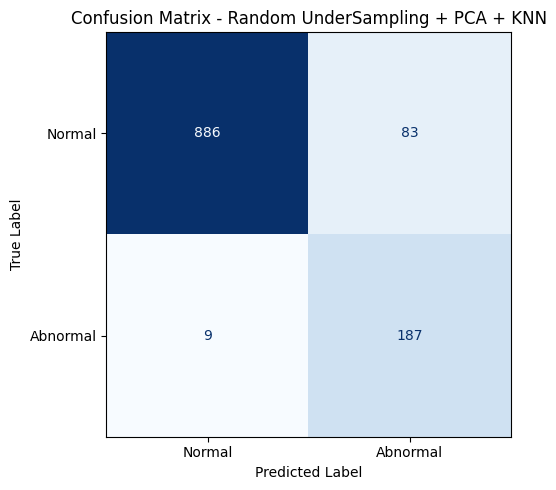

In [11]:
# ========= Random UnderSampling + PCA(固定維度) + KNN Search + Cross Validation =========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

from sklearn.model_selection import StratifiedKFold, ParameterGrid, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# =====================================
# 先看原本 training set 分布
# =====================================
print("=== Original Training Set ===")
print("X_train shape:", X_train.shape)
print("y_train distribution:", np.bincount(y_train))

# =====================================
# PCA 固定維度設定（符合老師要求）
# =====================================
PCA_SETTINGS_FIXED = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

# =====================================
# 交叉驗證設定
# =====================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline：採樣 -> 標準化 -> PCA -> KNN
pipe = Pipeline([
    ("sampler", RandomUnderSampler(random_state=42)),
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("knn", KNeighborsClassifier(metric='minkowski', p=1))   # Manhattan
])

# 評估指標
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro"
}

# =====================================
# 參數搜尋 + 交叉驗證
# =====================================
results = []

param_grid = {
    "pca__n_components": PCA_SETTINGS_FIXED,
    "knn__n_neighbors": K_LIST,
    "knn__weights": WEIGHT_LIST
}

for params in ParameterGrid(param_grid):
    pipe.set_params(**params)

    cv_result = cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    results.append({
        "PCA_components": params["pca__n_components"],
        "KNN_k": params["knn__n_neighbors"],
        "weights": params["knn__weights"],
        "CV_Accuracy_mean": np.mean(cv_result["test_accuracy"]),
        "CV_Accuracy_std": np.std(cv_result["test_accuracy"]),
        "CV_Balanced_Accuracy_mean": np.mean(cv_result["test_balanced_accuracy"]),
        "CV_Balanced_Accuracy_std": np.std(cv_result["test_balanced_accuracy"]),
        "CV_Macro_F1_mean": np.mean(cv_result["test_f1_macro"]),
        "CV_Macro_F1_std": np.std(cv_result["test_f1_macro"])
    })

results_df = pd.DataFrame(results).sort_values(
    by=["CV_Balanced_Accuracy_mean", "CV_Macro_F1_mean", "CV_Accuracy_mean"],
    ascending=False
).reset_index(drop=True)

display(results_df.head(20))

# =====================================
# 最佳參數
# =====================================
best = results_df.iloc[0]

best_pca_components = int(best["PCA_components"])
best_k = int(best["KNN_k"])
best_weights = best["weights"]

print("=== Best Cross-Validation Result ===")
print("Best PCA components:", best_pca_components)
print("Best K:", best_k)
print("Metric: Manhattan (Minkowski p=1)")
print("Weights:", best_weights)
print("CV Accuracy (mean ± std):",
      f'{best["CV_Accuracy_mean"]:.4f} ± {best["CV_Accuracy_std"]:.4f}')
print("CV Balanced Accuracy (mean ± std):",
      f'{best["CV_Balanced_Accuracy_mean"]:.4f} ± {best["CV_Balanced_Accuracy_std"]:.4f}')
print("CV Macro F1 (mean ± std):",
      f'{best["CV_Macro_F1_mean"]:.4f} ± {best["CV_Macro_F1_std"]:.4f}')

# =====================================
# 用最佳參數回頭訓練整個 training set
# 再到 test set 做最終評估
# =====================================
sampler = RandomUnderSampler(random_state=42)
X_train_model, y_train_model = sampler.fit_resample(X_train, y_train)

print("\n=== Random UnderSampling on Full Training Set ===")
print("Before sampling:\n", X_train.shape, np.bincount(y_train))
print("After sampling :\n", X_train_model.shape, np.bincount(y_train_model))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=best_pca_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='minkowski',
    p=1,
    weights=best_weights
)
knn.fit(X_train_pca, y_train_model)

y_pred = knn.predict(X_test_pca)

print("\n=== Final Test Result ===")
print("Best PCA components:", best_pca_components)
print("Best K:", best_k)
print("Metric: Manhattan (Minkowski p=1)")
print("Weights:", best_weights)
print("Accuracy:\n", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:\n", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:\n", f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("\nPCA components used:", pca.n_components_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.sum())

# =====================================
# 圖形化混淆矩陣
# =====================================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)

plt.title("Confusion Matrix - Random UnderSampling + PCA + KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

   PCA_components  CV_Accuracy_mean  CV_Balanced_Accuracy_mean  \
0               2          0.923931                   0.937431   
1               3          0.927842                   0.939714   
2               4          0.927453                   0.940790   
3               5          0.927059                   0.940675   
4               6          0.925692                   0.936940   
5               8          0.921977                   0.934732   
6              10          0.920217                   0.933003   
7              12          0.919628                   0.931275   
8              15          0.919824                   0.932997   
9              20          0.921585                   0.933679   

   CV_Macro_F1_mean  
0          0.888496  
1          0.893422  
2          0.893158  
3          0.892903  
4          0.890442  
5          0.885833  
6          0.883307  
7          0.882712  
8          0.883018  
9          0.885282  


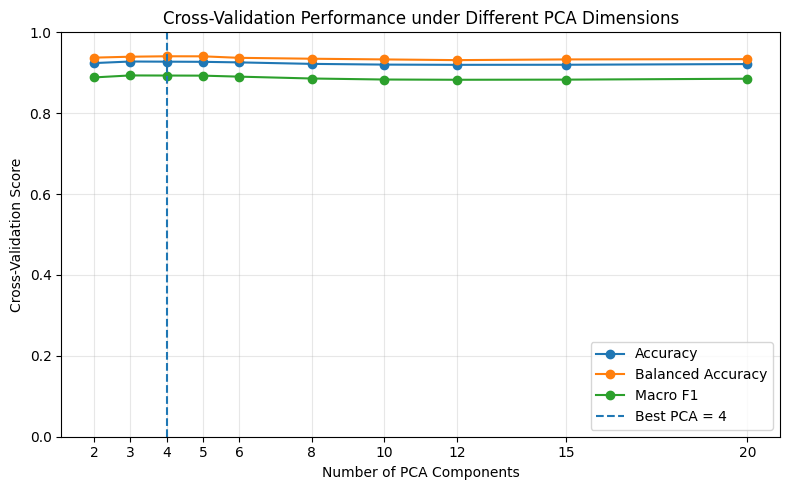

In [12]:
# =====================================
# PCA 最佳化過程圖
# 不同 PCA 維度下的最佳 CV 表現
# =====================================
import matplotlib.pyplot as plt

# 對每個 PCA 維度，找出該維度下表現最好的參數組合
pca_plot_df = results_df.groupby("PCA_components", as_index=False).agg({
    "CV_Accuracy_mean": "max",
    "CV_Balanced_Accuracy_mean": "max",
    "CV_Macro_F1_mean": "max"
}).sort_values("PCA_components")

print(pca_plot_df)

plt.figure(figsize=(8, 5))

plt.plot(
    pca_plot_df["PCA_components"],
    pca_plot_df["CV_Accuracy_mean"],
    marker='o',
    label="Accuracy"
)

plt.plot(
    pca_plot_df["PCA_components"],
    pca_plot_df["CV_Balanced_Accuracy_mean"],
    marker='o',
    label="Balanced Accuracy"
)

plt.plot(
    pca_plot_df["PCA_components"],
    pca_plot_df["CV_Macro_F1_mean"],
    marker='o',
    label="Macro F1"
)

# 標出最佳 PCA 維度
best_pca = int(best["PCA_components"])
best_bal_acc = float(best["CV_Balanced_Accuracy_mean"])

plt.axvline(x=best_pca, linestyle='--', label=f'Best PCA = {best_pca}')

plt.xlabel("Number of PCA Components")
plt.ylabel("Cross-Validation Score")
plt.title("Cross-Validation Performance under Different PCA Dimensions")
plt.xticks(pca_plot_df["PCA_components"])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

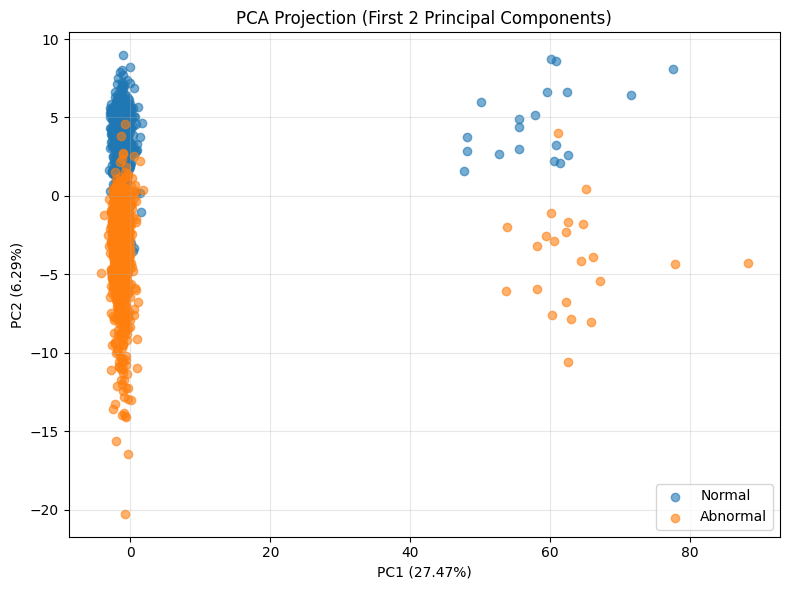

PC1 explained variance ratio: 0.27469042
PC2 explained variance ratio: 0.062926024
PC1 + PC2 total explained variance: 0.33761644


In [13]:
# =====================================
# 圖 2：PCA 前兩個主成分散點圖
# =====================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 標準化
scaler_2d = StandardScaler()
X_train_scaled_2d = scaler_2d.fit_transform(X_train_model)

# 投影到前兩個主成分
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled_2d)

label_names = {0: "Normal", 1: "Abnormal"}

plt.figure(figsize=(8, 6))

for label in np.unique(y_train_model):
    idx = (y_train_model == label)
    plt.scatter(
        X_train_pca_2d[idx, 0],
        X_train_pca_2d[idx, 1],
        alpha=0.6,
        label=label_names[label]
    )

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA Projection (First 2 Principal Components)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("PC1 explained variance ratio:", pca_2d.explained_variance_ratio_[0])
print("PC2 explained variance ratio:", pca_2d.explained_variance_ratio_[1])
print("PC1 + PC2 total explained variance:", pca_2d.explained_variance_ratio_.sum())

原始特徵數: 19
移除後特徵數: 17
移除欄位: ['MAX_BLOOD', 'MIN_BLOOD']
✅ 已建立 global_medians_ablation

===== Ablation Dataset Built =====
候選 session 數: 42268
保留 session 數: 6288
略過 session 數: 35980
X_ablation shape: (6288, 289)
y_ablation shape: (6288,)
Label distribution: [4257 2031]

===== Group-aware Split =====
Train shape: (5122, 289) [3424 1698]
Test shape : (1166, 289) [833 333]
Train groups: 64
Test groups : 16
Group overlap: 0

===== Ablation CV Top Results =====


,PCA_components,KNN_k,weights,CV_Accuracy_mean,CV_Accuracy_std,CV_Balanced_Accuracy_mean,CV_Balanced_Accuracy_std,CV_Macro_F1_mean,CV_Macro_F1_std
0,15,11,uniform,0.833461,0.009605,0.845292,0.007833,0.822384,0.009275
1,15,9,distance,0.833070,0.012363,0.844408,0.010249,0.821872,0.012063
2,15,7,uniform,0.832290,0.010022,0.844122,0.008719,0.821161,0.009692
3,15,9,uniform,0.832679,0.013214,0.844116,0.011069,0.821498,0.012952
4,15,11,distance,0.832485,0.010203,0.843969,0.008563,0.821292,0.009948
5,15,7,distance,0.832485,0.009992,0.843674,0.009404,0.821188,0.009811
6,12,11,uniform,0.832289,0.014238,0.843528,0.013373,0.821041,0.014353
7,15,19,distance,0.831900,0.014295,0.843388,0.012402,0.820715,0.014121
8,12,15,distance,0.832875,0.010759,0.843225,0.010443,0.821404,0.010871
9,15,15,distance,0.831118,0.009646,0.842798,0.007049,0.819930,0.009109


=== Ablation Best Cross-Validation Result ===
Best PCA components: 15
Best K: 11
Metric: Manhattan (Minkowski p=1)
Weights: uniform
CV Accuracy (mean ± std): 0.8335 ± 0.0096
CV Balanced Accuracy (mean ± std): 0.8453 ± 0.0078
CV Macro F1 (mean ± std): 0.8224 ± 0.0093

=== Random UnderSampling on Full Training Set (Ablation) ===
Before sampling:
 (5122, 289) [3424 1698]
After sampling :
 (3396, 289) [1698 1698]

=== Ablation Final Test Result ===
Best PCA components: 15
Best K: 11
Metric: Manhattan (Minkowski p=1)
Weights: uniform
Accuracy: 0.79073756432247
Balanced Accuracy: 0.8210960059699555
Macro F1: 0.7727553012367688

Classification Report:
               precision    recall  f1-score   support

           0     0.9455    0.7503    0.8367       833
           1     0.5881    0.8919    0.7088       333

    accuracy                         0.7907      1166
   macro avg     0.7668    0.8211    0.7728      1166
weighted avg     0.8435    0.7907    0.8002      1166


PCA components use

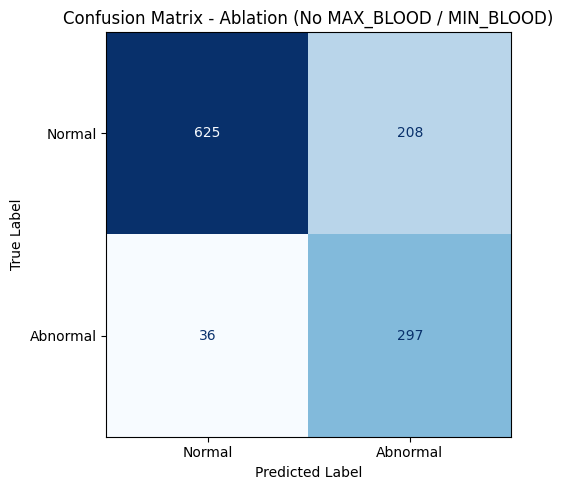


===== PCA Dimension Optimization Table (Ablation) =====
   PCA_components  CV_Accuracy_mean  CV_Balanced_Accuracy_mean  \
0               2          0.585704                   0.590641   
1               3          0.656189                   0.663184   
2               4          0.771380                   0.772291   
3               5          0.793631                   0.793697   
4               6          0.795778                   0.802124   
5               8          0.817839                   0.827225   
6              10          0.828188                   0.840754   
7              12          0.832875                   0.843528   
8              15          0.833461                   0.845292   
9              20          0.832682                   0.841745   

   CV_Macro_F1_mean  
0          0.570577  
1          0.641137  
2          0.755275  
3          0.777696  
4          0.781886  
5          0.805639  
6          0.817128  
7          0.821404  
8          0.82238

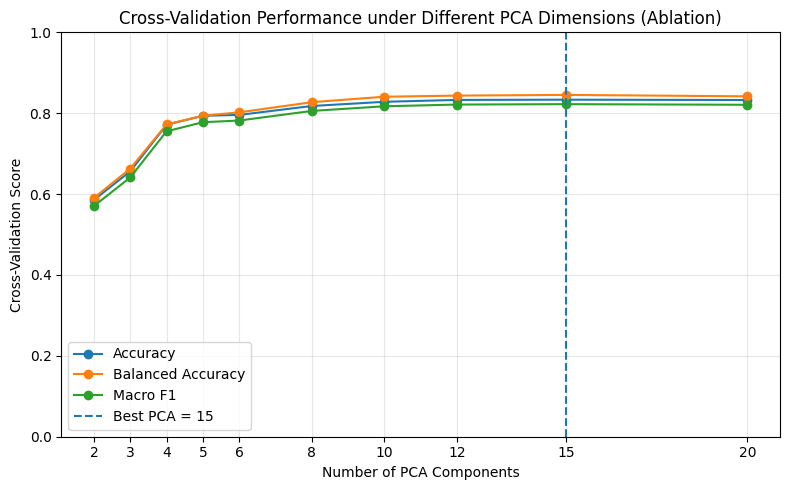

In [16]:
# =========================================================
# Ablation Study:
# 移除 MAX_BLOOD、MIN_BLOOD 後重新建立資料集並做 PCA + KNN
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, ParameterGrid, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# =========================================================
# 0. 建立移除血壓欄位後的特徵清單
# =========================================================
feature_cols_ablation = [
    col for col in all_feature_columns
    if col not in ["MAX_BLOOD", "MIN_BLOOD"]
]

print("原始特徵數:", len(all_feature_columns))
print("移除後特徵數:", len(feature_cols_ablation))
print("移除欄位:", [c for c in ["MAX_BLOOD", "MIN_BLOOD"] if c in all_feature_columns])

# =========================================================
# 1. 建立 global medians（只針對移除後特徵）
# =========================================================
value_pool_ablation = {col: [] for col in feature_cols_ablation}

for item in usable_file_items:
    df = item["data"].copy()

    numeric_df = df.select_dtypes(include=[np.number]).copy()
    numeric_df = numeric_df.drop(columns=["PAT_NO"], errors="ignore")
    numeric_df = numeric_df.reindex(columns=feature_cols_ablation)

    for col in feature_cols_ablation:
        vals = pd.to_numeric(numeric_df[col], errors="coerce").dropna().values
        if len(vals) > 0:
            value_pool_ablation[col].extend(vals.tolist())

global_medians_ablation = {}
for col in feature_cols_ablation:
    global_medians_ablation[col] = (
        float(np.median(value_pool_ablation[col]))
        if len(value_pool_ablation[col]) > 0 else 0.0
    )

print("✅ 已建立 global_medians_ablation")


# =========================================================
# 2. session 切分
# =========================================================
def assign_sessions(df_in, patient_col='PAT_NO',
                    time_col='REC_DATE',
                    gap_hours=6):
    df_in = df_in.copy()
    df_in = df_in.sort_values([patient_col, time_col]).reset_index(drop=True)

    session_ids = []
    current_session = 0
    prev_patient = None
    prev_time = None

    for _, row in df_in.iterrows():
        patient = row[patient_col]
        t = row[time_col]

        new_session = False
        if prev_patient is None:
            new_session = True
        elif patient != prev_patient:
            new_session = True
        else:
            delta_hours = (t - prev_time).total_seconds() / 3600.0
            if delta_hours > gap_hours:
                new_session = True

        if new_session:
            current_session += 1

        session_ids.append(f"S{current_session:05d}")
        prev_patient = patient
        prev_time = t

    df_in["SESSION_ID"] = session_ids
    return df_in


# =========================================================
# 3. session 清洗
# =========================================================
def clean_session_df(session_df, feature_cols, global_medians,
                     min_len=30, core_missing_ratio=0.6):
    x = session_df[feature_cols].copy()

    # 先全部強制轉成 numeric，不能轉的變 NaN
    for col in feature_cols:
        x[col] = pd.to_numeric(x[col], errors='coerce')

    # 保留有效值比例夠高的列
    row_valid_ratio = x.notna().mean(axis=1)
    x = x[row_valid_ratio >= core_missing_ratio].copy()

    if len(x) < min_len:
        return None

    # 線性插值 + 前補後補
    x = x.interpolate(method="linear", limit_direction="both", axis=0)
    x = x.ffill().bfill()

    # 逐欄補值
    for col in feature_cols:
        if x[col].isna().all():
            x[col] = global_medians[col]
        else:
            col_median = pd.to_numeric(x[col], errors='coerce').median()
            if pd.isna(col_median):
                x[col] = x[col].fillna(global_medians[col])
            else:
                x[col] = x[col].fillna(col_median)

    # 最後保底再補一次
    x = x.fillna(pd.Series(global_medians))

    return x

# =========================================================
# 4. Rule 標籤（保留原本規則，不修改）
#    label 仍然用完整資料算
# =========================================================
def rule_based_label(df_feat,
                     sbp_col='MAX_BLOOD',
                     dbp_col='MIN_BLOOD',
                     low_threshold=LOW_THRESHOLD,
                     drop_threshold=DROP_THRESHOLD,
                     dbp_low_threshold=DBP_LOW_THRESHOLD):
    """
    1 = abnormal
    0 = normal

    規則：
    A. 收縮壓最低值 < low_threshold
    B. 收縮壓相對起始 baseline 下降 >= drop_threshold
    C. 舒張壓最低值 < dbp_low_threshold

    判異常條件：
    (A and B) 或 (A and C)
    """

    if sbp_col not in df_feat.columns:
        return 0

    sbp = pd.to_numeric(df_feat[sbp_col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if len(sbp) < 5:
        return 0

    sbp = sbp.values.astype(float)

    baseline = np.mean(sbp[:5])
    sbp_min = np.min(sbp)
    sbp_drop = baseline - sbp_min

    rule_a = sbp_min < low_threshold
    rule_b = sbp_drop >= drop_threshold

    rule_c = False
    if dbp_col in df_feat.columns:
        dbp = pd.to_numeric(df_feat[dbp_col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
        if len(dbp) >= 5:
            dbp = dbp.values.astype(float)
            dbp_min = np.min(dbp)
            rule_c = dbp_min < dbp_low_threshold

    if (rule_a and rule_b) or (rule_a and rule_c):
        return 1
    return 0


# =========================================================
# 5. 統計特徵萃取（移除 MIN_BLOOD 特別設計特徵）
# =========================================================
def extract_stat_features_ablation(df_feat):
    diff = df_feat.diff().fillna(0)
    n = len(df_feat)

    s1 = df_feat.iloc[:max(1, n // 3)]
    s2 = df_feat.iloc[max(1, n // 3):max(2, 2 * n // 3)]
    s3 = df_feat.iloc[max(2, 2 * n // 3):]

    slopes = []
    x_idx = np.arange(len(df_feat))

    for col in df_feat.columns:
        vals = pd.to_numeric(df_feat[col], errors='coerce').ffill().bfill().fillna(0).values
        if len(vals) >= 2 and np.std(vals) > 1e-8:
            m = np.polyfit(x_idx, vals, 1)[0]
        else:
            m = 0.0
        slopes.append(m)

    feats = np.concatenate([
        df_feat.mean().values,
        df_feat.std(ddof=0).values,
        df_feat.min().values,
        df_feat.max().values,
        df_feat.median().values,
        df_feat.quantile(0.25).values,
        df_feat.quantile(0.75).values,
        (df_feat.max() - df_feat.min()).values,
        df_feat.iloc[0].values,
        df_feat.iloc[-1].values,
        (df_feat.iloc[-1] - df_feat.iloc[0]).values,
        diff.abs().mean().values,
        diff.abs().std(ddof=0).values,
        s1.mean().values,
        s2.mean().values,
        s3.mean().values,
        np.array(slopes, dtype=np.float32)
    ]).astype(np.float32)

    return feats


# =========================================================
# 6. 重新建立資料集
#    label 用完整資料 g 算
#    feature 用移除血壓欄位的 cleaned session
# =========================================================
X_ablation = []
y_ablation = []
session_meta_ablation = []

candidate_session_count = 0
kept_session_count = 0
skipped_session_count = 0

for item in usable_file_items:
    df = item["data"].copy()

    # 固定病人欄位
    patient_col = "PAT_NO"

    if patient_col not in df.columns:
        print("⚠️ 找不到 PAT_NO，跳過檔案：", item.get("file_name", "unknown_file"))
        continue

    # 自動偵測時間欄位
    if "REC_DATE" in df.columns:
        time_col = "REC_DATE"
    elif "DATA_TIME" in df.columns:
        time_col = "DATA_TIME"
    elif "UDATE" in df.columns:
        time_col = "UDATE"
    else:
        print("⚠️ 找不到時間欄位，跳過檔案：", item.get("file_name", "unknown_file"))
        continue

    # 轉成 datetime，失敗的變 NaT
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[patient_col, time_col]).copy()

    if len(df) == 0:
        print("⚠️ 清理後資料為空，跳過檔案：", item.get("file_name", "unknown_file"))
        continue

    source_folder = item.get("source_folder", "unknown_folder")
    file_name = item.get("file_name", "unknown_file")

    # 切 session
    df = assign_sessions(
        df,
        patient_col=patient_col,
        time_col=time_col,
        gap_hours=6
    )

    for sid, g in df.groupby("SESSION_ID"):
        candidate_session_count += 1

        # label 用完整資料
        label = rule_based_label(g)

        # feature 用移除血壓欄位的版本
        cleaned = clean_session_df(
            g,
            feature_cols=feature_cols_ablation,
            global_medians=global_medians_ablation,
            min_len=30,
            core_missing_ratio=0.6
        )

        if cleaned is None:
            skipped_session_count += 1
            continue

        feats = extract_stat_features_ablation(cleaned)

        X_ablation.append(feats)
        y_ablation.append(label)

        patient_val = g[patient_col].iloc[0] if patient_col in g.columns else "UNK"

        session_meta_ablation.append({
            "SESSION_ID": sid,
            "source_folder": source_folder,
            "file_name": file_name,
            "patient_no": patient_val,
            "label": label,
            "session_len": len(cleaned)
        })

        kept_session_count += 1

X_ablation = np.array(X_ablation, dtype=np.float32)
y_ablation = np.array(y_ablation, dtype=np.int64)
session_meta_ablation_df = pd.DataFrame(session_meta_ablation)

print("\n===== Ablation Dataset Built =====")
print("候選 session 數:", candidate_session_count)
print("保留 session 數:", kept_session_count)
print("略過 session 數:", skipped_session_count)
print("X_ablation shape:", X_ablation.shape)
print("y_ablation shape:", y_ablation.shape)
print("Label distribution:", np.bincount(y_ablation))


# =========================================================
# 7. Group-aware split
# =========================================================
groups_ablation = (
    session_meta_ablation_df["source_folder"].astype(str) + "_" +
    session_meta_ablation_df["file_name"].astype(str) + "_" +
    session_meta_ablation_df["patient_no"].astype(str)
).values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_ab, test_idx_ab = next(gss.split(X_ablation, y_ablation, groups=groups_ablation))

X_train_ab = X_ablation[train_idx_ab]
X_test_ab = X_ablation[test_idx_ab]
y_train_ab = y_ablation[train_idx_ab]
y_test_ab = y_ablation[test_idx_ab]
groups_train_ab = groups_ablation[train_idx_ab]
groups_test_ab = groups_ablation[test_idx_ab]

print("\n===== Group-aware Split =====")
print("Train shape:", X_train_ab.shape, np.bincount(y_train_ab))
print("Test shape :", X_test_ab.shape, np.bincount(y_test_ab))
print("Train groups:", len(np.unique(groups_train_ab)))
print("Test groups :", len(np.unique(groups_test_ab)))
print("Group overlap:", len(set(groups_train_ab) & set(groups_test_ab)))


# =========================================================
# 8. Random UnderSampling + PCA(固定維度) + KNN + CV
# =========================================================
PCA_SETTINGS_FIXED = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([
    ("sampler", RandomUnderSampler(random_state=42)),
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("knn", KNeighborsClassifier(metric="minkowski", p=1))
])

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro"
}

param_grid = {
    "pca__n_components": PCA_SETTINGS_FIXED,
    "knn__n_neighbors": K_LIST,
    "knn__weights": WEIGHT_LIST
}

results_ab = []

for params in ParameterGrid(param_grid):
    pipe.set_params(**params)

    cv_result = cross_validate(
        estimator=pipe,
        X=X_train_ab,
        y=y_train_ab,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    results_ab.append({
        "PCA_components": params["pca__n_components"],
        "KNN_k": params["knn__n_neighbors"],
        "weights": params["knn__weights"],
        "CV_Accuracy_mean": np.mean(cv_result["test_accuracy"]),
        "CV_Accuracy_std": np.std(cv_result["test_accuracy"]),
        "CV_Balanced_Accuracy_mean": np.mean(cv_result["test_balanced_accuracy"]),
        "CV_Balanced_Accuracy_std": np.std(cv_result["test_balanced_accuracy"]),
        "CV_Macro_F1_mean": np.mean(cv_result["test_f1_macro"]),
        "CV_Macro_F1_std": np.std(cv_result["test_f1_macro"])
    })

results_ab_df = pd.DataFrame(results_ab).sort_values(
    by=["CV_Balanced_Accuracy_mean", "CV_Macro_F1_mean", "CV_Accuracy_mean"],
    ascending=False
).reset_index(drop=True)

print("\n===== Ablation CV Top Results =====")
display(results_ab_df.head(20))


# =========================================================
# 9. 顯示最佳參數
# =========================================================
best_ab = results_ab_df.iloc[0]

best_pca_ab = int(best_ab["PCA_components"])
best_k_ab = int(best_ab["KNN_k"])
best_weights_ab = best_ab["weights"]

print("=== Ablation Best Cross-Validation Result ===")
print("Best PCA components:", best_pca_ab)
print("Best K:", best_k_ab)
print("Metric: Manhattan (Minkowski p=1)")
print("Weights:", best_weights_ab)
print("CV Accuracy (mean ± std):",
      f'{best_ab["CV_Accuracy_mean"]:.4f} ± {best_ab["CV_Accuracy_std"]:.4f}')
print("CV Balanced Accuracy (mean ± std):",
      f'{best_ab["CV_Balanced_Accuracy_mean"]:.4f} ± {best_ab["CV_Balanced_Accuracy_std"]:.4f}')
print("CV Macro F1 (mean ± std):",
      f'{best_ab["CV_Macro_F1_mean"]:.4f} ± {best_ab["CV_Macro_F1_std"]:.4f}')


# =========================================================
# 10. 用最佳參數回頭訓練整個 training set，然後到 test 評估
# =========================================================
sampler = RandomUnderSampler(random_state=42)
X_train_model_ab, y_train_model_ab = sampler.fit_resample(X_train_ab, y_train_ab)

print("\n=== Random UnderSampling on Full Training Set (Ablation) ===")
print("Before sampling:\n", X_train_ab.shape, np.bincount(y_train_ab))
print("After sampling :\n", X_train_model_ab.shape, np.bincount(y_train_model_ab))

scaler = StandardScaler()
X_train_scaled_ab = scaler.fit_transform(X_train_model_ab)
X_test_scaled_ab = scaler.transform(X_test_ab)

pca = PCA(n_components=best_pca_ab)
X_train_pca_ab = pca.fit_transform(X_train_scaled_ab)
X_test_pca_ab = pca.transform(X_test_scaled_ab)

knn = KNeighborsClassifier(
    n_neighbors=best_k_ab,
    metric="minkowski",
    p=1,
    weights=best_weights_ab
)
knn.fit(X_train_pca_ab, y_train_model_ab)

y_pred_ab = knn.predict(X_test_pca_ab)

print("\n=== Ablation Final Test Result ===")
print("Best PCA components:", best_pca_ab)
print("Best K:", best_k_ab)
print("Metric: Manhattan (Minkowski p=1)")
print("Weights:", best_weights_ab)
print("Accuracy:", accuracy_score(y_test_ab, y_pred_ab))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_ab, y_pred_ab))
print("Macro F1:", f1_score(y_test_ab, y_pred_ab, average="macro"))
print("\nClassification Report:\n", classification_report(y_test_ab, y_pred_ab, digits=4))
print("\nPCA components used:", pca.n_components_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.sum())


# =========================================================
# 11. 混淆矩陣
# =========================================================
cm_ab = confusion_matrix(y_test_ab, y_pred_ab)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ab,
    display_labels=["Normal", "Abnormal"]
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)

plt.title("Confusion Matrix - Ablation (No MAX_BLOOD / MIN_BLOOD)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# =========================================================
# 12. PCA 維度最佳化圖
# =========================================================
pca_plot_df_ab = results_ab_df.groupby("PCA_components", as_index=False).agg({
    "CV_Accuracy_mean": "max",
    "CV_Balanced_Accuracy_mean": "max",
    "CV_Macro_F1_mean": "max"
}).sort_values("PCA_components")

print("\n===== PCA Dimension Optimization Table (Ablation) =====")
print(pca_plot_df_ab)

plt.figure(figsize=(8, 5))
plt.plot(
    pca_plot_df_ab["PCA_components"],
    pca_plot_df_ab["CV_Accuracy_mean"],
    marker='o',
    label="Accuracy"
)
plt.plot(
    pca_plot_df_ab["PCA_components"],
    pca_plot_df_ab["CV_Balanced_Accuracy_mean"],
    marker='o',
    label="Balanced Accuracy"
)
plt.plot(
    pca_plot_df_ab["PCA_components"],
    pca_plot_df_ab["CV_Macro_F1_mean"],
    marker='o',
    label="Macro F1"
)

plt.axvline(x=best_pca_ab, linestyle='--', label=f'Best PCA = {best_pca_ab}')

plt.xlabel("Number of PCA Components")
plt.ylabel("Cross-Validation Score")
plt.title("Cross-Validation Performance under Different PCA Dimensions (Ablation)")
plt.xticks(pca_plot_df_ab["PCA_components"])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Original Training Set ===
X_train shape: (5114, 328)
y_train distribution: [4156  958]


,PCA_components,KNN_k,weights,CV_Accuracy_mean,CV_Accuracy_std,CV_Balanced_Accuracy_mean,CV_Balanced_Accuracy_std,CV_Macro_F1_mean,CV_Macro_F1_std
0,5,15,uniform,0.932146,0.007317,0.942602,0.005069,0.899143,0.009452
1,4,19,uniform,0.932536,0.009267,0.942444,0.008484,0.899631,0.012353
2,5,19,uniform,0.932537,0.008214,0.942441,0.005777,0.899627,0.010553
3,6,15,distance,0.935666,0.007562,0.942354,0.005612,0.903438,0.009786
4,4,15,uniform,0.932147,0.006681,0.942199,0.006268,0.899035,0.008922
5,5,19,distance,0.933906,0.007236,0.942080,0.007343,0.901182,0.009590
6,3,19,uniform,0.930777,0.006938,0.941754,0.005311,0.897339,0.008679
7,3,19,distance,0.931950,0.006744,0.941675,0.007022,0.898716,0.008920
8,5,15,distance,0.932928,0.006154,0.941481,0.006113,0.899870,0.007872
9,4,15,distance,0.933320,0.008194,0.941315,0.007206,0.900372,0.010813


=== Best Cross-Validation Result ===
Best PCA components: 5
Best K: 15
Metric: Manhattan (Minkowski p=1)
Weights: uniform
CV Accuracy (mean ± std): 0.9321 ± 0.0073
CV Balanced Accuracy (mean ± std): 0.9426 ± 0.0051
CV Macro F1 (mean ± std): 0.8991 ± 0.0095

=== Random OverSampling on Full Training Set ===
Before sampling:
 (5114, 328) [4156  958]
After sampling :
 (8312, 328) [4156 4156]

=== Final Test Result ===
Best PCA components: 5
Best K: 15
Metric: Manhattan (Minkowski p=1)
Weights: uniform
Accuracy:
 0.9236051502145923
Balanced Accuracy:
 0.9174459257387165
Macro F1:
 0.8763925729442972

Classification Report:
               precision    recall  f1-score   support

           0     0.9803    0.9267    0.9528       969
           1     0.7149    0.9082    0.8000       196

    accuracy                         0.9236      1165
   macro avg     0.8476    0.9174    0.8764      1165
weighted avg     0.9357    0.9236    0.9271      1165


PCA components used: 5
Cumulative explained v

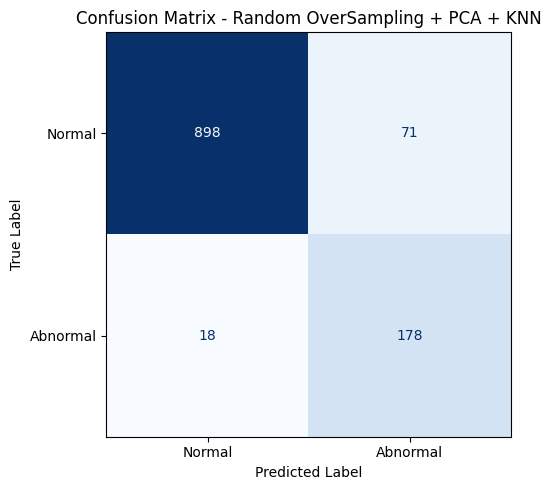

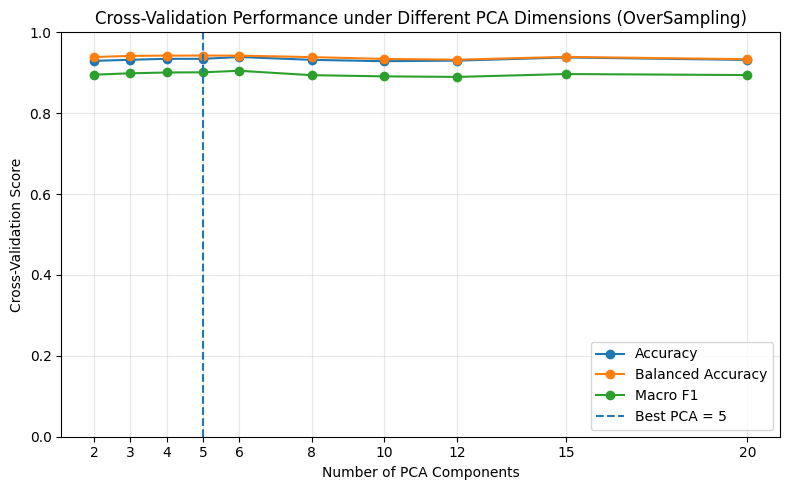

In [17]:
# ========= Random OverSampling + PCA(固定維度) + KNN Search + Cross Validation =========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

from sklearn.model_selection import StratifiedKFold, ParameterGrid, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# =====================================
# 先看原本 training set 分布
# =====================================
print("=== Original Training Set ===")
print("X_train shape:", X_train.shape)
print("y_train distribution:", np.bincount(y_train))

# =====================================
# PCA 固定維度設定
# =====================================
PCA_SETTINGS_FIXED = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

# =====================================
# 交叉驗證設定
# =====================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline：採樣 -> 標準化 -> PCA -> KNN
pipe = Pipeline([
    ("sampler", RandomOverSampler(random_state=42)),
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("knn", KNeighborsClassifier(metric='minkowski', p=1))   # Manhattan
])

# 評估指標
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro"
}

# =====================================
# 參數搜尋 + 交叉驗證
# =====================================
results = []

param_grid = {
    "pca__n_components": PCA_SETTINGS_FIXED,
    "knn__n_neighbors": K_LIST,
    "knn__weights": WEIGHT_LIST
}

for params in ParameterGrid(param_grid):
    pipe.set_params(**params)

    cv_result = cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    results.append({
        "PCA_components": params["pca__n_components"],
        "KNN_k": params["knn__n_neighbors"],
        "weights": params["knn__weights"],
        "CV_Accuracy_mean": np.mean(cv_result["test_accuracy"]),
        "CV_Accuracy_std": np.std(cv_result["test_accuracy"]),
        "CV_Balanced_Accuracy_mean": np.mean(cv_result["test_balanced_accuracy"]),
        "CV_Balanced_Accuracy_std": np.std(cv_result["test_balanced_accuracy"]),
        "CV_Macro_F1_mean": np.mean(cv_result["test_f1_macro"]),
        "CV_Macro_F1_std": np.std(cv_result["test_f1_macro"])
    })

results_df = pd.DataFrame(results).sort_values(
    by=["CV_Balanced_Accuracy_mean", "CV_Macro_F1_mean", "CV_Accuracy_mean"],
    ascending=False
).reset_index(drop=True)

display(results_df.head(20))

# =====================================
# 最佳參數
# =====================================
best = results_df.iloc[0]

best_pca_components = int(best["PCA_components"])
best_k = int(best["KNN_k"])
best_weights = best["weights"]

print("=== Best Cross-Validation Result ===")
print("Best PCA components:", best_pca_components)
print("Best K:", best_k)
print("Metric: Manhattan (Minkowski p=1)")
print("Weights:", best_weights)
print("CV Accuracy (mean ± std):",
      f'{best["CV_Accuracy_mean"]:.4f} ± {best["CV_Accuracy_std"]:.4f}')
print("CV Balanced Accuracy (mean ± std):",
      f'{best["CV_Balanced_Accuracy_mean"]:.4f} ± {best["CV_Balanced_Accuracy_std"]:.4f}')
print("CV Macro F1 (mean ± std):",
      f'{best["CV_Macro_F1_mean"]:.4f} ± {best["CV_Macro_F1_std"]:.4f}')

# =====================================
# 用最佳參數回頭訓練整個 training set
# 再到 test set 做最終評估
# =====================================
sampler = RandomOverSampler(random_state=42)
X_train_model, y_train_model = sampler.fit_resample(X_train, y_train)

print("\n=== Random OverSampling on Full Training Set ===")
print("Before sampling:\n", X_train.shape, np.bincount(y_train))
print("After sampling :\n", X_train_model.shape, np.bincount(y_train_model))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=best_pca_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='minkowski',
    p=1,
    weights=best_weights
)
knn.fit(X_train_pca, y_train_model)

y_pred = knn.predict(X_test_pca)

print("\n=== Final Test Result ===")
print("Best PCA components:", best_pca_components)
print("Best K:", best_k)
print("Metric: Manhattan (Minkowski p=1)")
print("Weights:", best_weights)
print("Accuracy:\n", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:\n", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:\n", f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("\nPCA components used:", pca.n_components_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.sum())

# =====================================
# 圖形化混淆矩陣
# =====================================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)

plt.title("Confusion Matrix - Random OverSampling + PCA + KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# =====================================
# PCA 維度最佳化圖
# =====================================
pca_plot_df = results_df.groupby("PCA_components", as_index=False).agg({
    "CV_Accuracy_mean": "max",
    "CV_Balanced_Accuracy_mean": "max",
    "CV_Macro_F1_mean": "max"
}).sort_values("PCA_components")

plt.figure(figsize=(8, 5))
plt.plot(pca_plot_df["PCA_components"], pca_plot_df["CV_Accuracy_mean"], marker='o', label="Accuracy")
plt.plot(pca_plot_df["PCA_components"], pca_plot_df["CV_Balanced_Accuracy_mean"], marker='o', label="Balanced Accuracy")
plt.plot(pca_plot_df["PCA_components"], pca_plot_df["CV_Macro_F1_mean"], marker='o', label="Macro F1")
plt.axvline(x=best_pca_components, linestyle='--', label=f'Best PCA = {best_pca_components}')

plt.xlabel("Number of PCA Components")
plt.ylabel("Cross-Validation Score")
plt.title("Cross-Validation Performance under Different PCA Dimensions (OverSampling)")
plt.xticks(pca_plot_df["PCA_components"])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Original Training Set ===
X_train shape: (5114, 328)
y_train distribution: [4156  958]


,PCA_components,KNN_k,weights,CV_Accuracy_mean,CV_Accuracy_std,CV_Balanced_Accuracy_mean,CV_Balanced_Accuracy_std,CV_Macro_F1_mean,CV_Macro_F1_std
0,5,19,uniform,0.941142,0.005547,0.944529,0.008276,0.910537,0.007458
1,5,19,distance,0.942706,0.003425,0.944287,0.009246,0.912429,0.004884
2,5,11,distance,0.943293,0.003449,0.944248,0.009965,0.913182,0.004627
3,5,15,uniform,0.941142,0.005582,0.943327,0.011033,0.910312,0.008020
4,5,15,distance,0.941728,0.004739,0.943288,0.012164,0.911010,0.007230
5,5,11,uniform,0.941533,0.004351,0.943168,0.011255,0.910755,0.006420
6,5,9,distance,0.942510,0.004526,0.942159,0.007409,0.911914,0.005697
7,4,9,uniform,0.940751,0.005818,0.941082,0.009700,0.909503,0.007944
8,3,19,uniform,0.937817,0.007073,0.940882,0.008145,0.905835,0.009270
9,3,19,distance,0.938991,0.005948,0.940806,0.009102,0.907258,0.007683


=== Best Cross-Validation Result ===
Best PCA components: 5
Best K: 19
Metric: Manhattan (Minkowski p=1)
Weights: uniform
CV Accuracy (mean ± std): 0.9411 ± 0.0055
CV Balanced Accuracy (mean ± std): 0.9445 ± 0.0083
CV Macro F1 (mean ± std): 0.9105 ± 0.0075

=== SMOTE on Full Training Set ===
Before sampling:
 (5114, 328) [4156  958]
After sampling :
 (8312, 328) [4156 4156]

=== Final Test Result ===
Best PCA components: 5
Best K: 19
Metric: Manhattan (Minkowski p=1)
Weights: uniform
Accuracy:
 0.9296137339055794
Balanced Accuracy:
 0.9210578968429477
Macro F1:
 0.8847225037890855

Classification Report:
               precision    recall  f1-score   support

           0     0.9805    0.9340    0.9567       969
           1     0.7355    0.9082    0.8128       196

    accuracy                         0.9296      1165
   macro avg     0.8580    0.9211    0.8847      1165
weighted avg     0.9393    0.9296    0.9325      1165


PCA components used: 5
Cumulative explained variance: 0.430

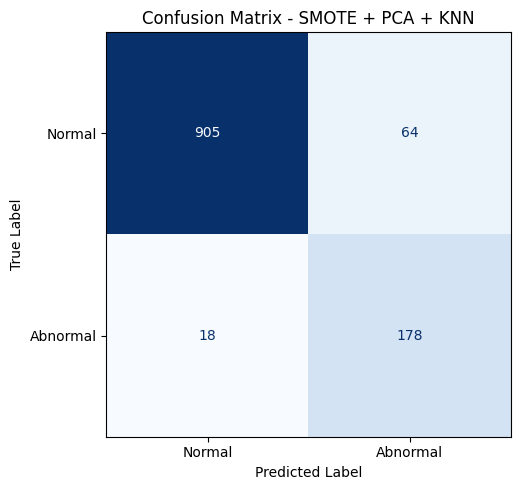

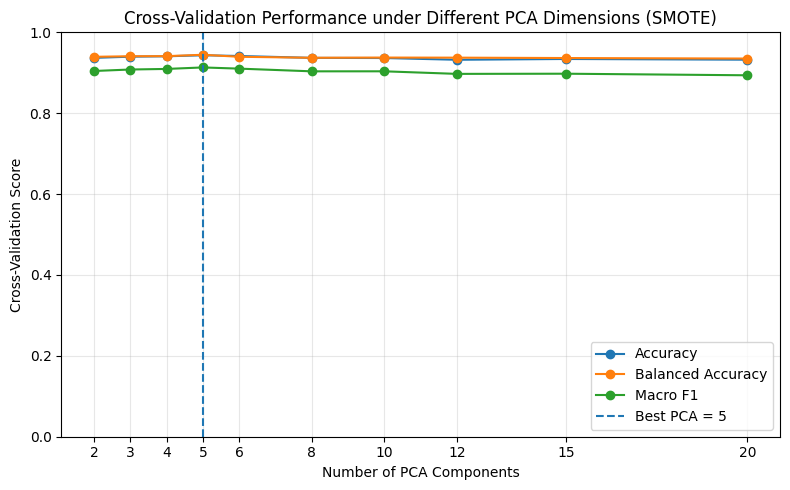

In [18]:
# ========= SMOTE + PCA(固定維度) + KNN Search + Cross Validation =========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.model_selection import StratifiedKFold, ParameterGrid, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# =====================================
# 先看原本 training set 分布
# =====================================
print("=== Original Training Set ===")
print("X_train shape:", X_train.shape)
print("y_train distribution:", np.bincount(y_train))

# =====================================
# PCA 固定維度設定
# =====================================
PCA_SETTINGS_FIXED = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

# =====================================
# 交叉驗證設定
# =====================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline：採樣 -> 標準化 -> PCA -> KNN
pipe = Pipeline([
    ("sampler", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("knn", KNeighborsClassifier(metric='minkowski', p=1))   # Manhattan
])

# 評估指標
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro"
}

# =====================================
# 參數搜尋 + 交叉驗證
# =====================================
results = []

param_grid = {
    "pca__n_components": PCA_SETTINGS_FIXED,
    "knn__n_neighbors": K_LIST,
    "knn__weights": WEIGHT_LIST
}

for params in ParameterGrid(param_grid):
    pipe.set_params(**params)

    cv_result = cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    results.append({
        "PCA_components": params["pca__n_components"],
        "KNN_k": params["knn__n_neighbors"],
        "weights": params["knn__weights"],
        "CV_Accuracy_mean": np.mean(cv_result["test_accuracy"]),
        "CV_Accuracy_std": np.std(cv_result["test_accuracy"]),
        "CV_Balanced_Accuracy_mean": np.mean(cv_result["test_balanced_accuracy"]),
        "CV_Balanced_Accuracy_std": np.std(cv_result["test_balanced_accuracy"]),
        "CV_Macro_F1_mean": np.mean(cv_result["test_f1_macro"]),
        "CV_Macro_F1_std": np.std(cv_result["test_f1_macro"])
    })

results_df = pd.DataFrame(results).sort_values(
    by=["CV_Balanced_Accuracy_mean", "CV_Macro_F1_mean", "CV_Accuracy_mean"],
    ascending=False
).reset_index(drop=True)

display(results_df.head(20))

# =====================================
# 最佳參數
# =====================================
best = results_df.iloc[0]

best_pca_components = int(best["PCA_components"])
best_k = int(best["KNN_k"])
best_weights = best["weights"]

print("=== Best Cross-Validation Result ===")
print("Best PCA components:", best_pca_components)
print("Best K:", best_k)
print("Metric: Manhattan (Minkowski p=1)")
print("Weights:", best_weights)
print("CV Accuracy (mean ± std):",
      f'{best["CV_Accuracy_mean"]:.4f} ± {best["CV_Accuracy_std"]:.4f}')
print("CV Balanced Accuracy (mean ± std):",
      f'{best["CV_Balanced_Accuracy_mean"]:.4f} ± {best["CV_Balanced_Accuracy_std"]:.4f}')
print("CV Macro F1 (mean ± std):",
      f'{best["CV_Macro_F1_mean"]:.4f} ± {best["CV_Macro_F1_std"]:.4f}')

# =====================================
# 用最佳參數回頭訓練整個 training set
# 再到 test set 做最終評估
# =====================================
sampler = SMOTE(random_state=42)
X_train_model, y_train_model = sampler.fit_resample(X_train, y_train)

print("\n=== SMOTE on Full Training Set ===")
print("Before sampling:\n", X_train.shape, np.bincount(y_train))
print("After sampling :\n", X_train_model.shape, np.bincount(y_train_model))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=best_pca_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='minkowski',
    p=1,
    weights=best_weights
)
knn.fit(X_train_pca, y_train_model)

y_pred = knn.predict(X_test_pca)

print("\n=== Final Test Result ===")
print("Best PCA components:", best_pca_components)
print("Best K:", best_k)
print("Metric: Manhattan (Minkowski p=1)")
print("Weights:", best_weights)
print("Accuracy:\n", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:\n", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:\n", f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("\nPCA components used:", pca.n_components_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.sum())

# =====================================
# 圖形化混淆矩陣
# =====================================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)

plt.title("Confusion Matrix - SMOTE + PCA + KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# =====================================
# PCA 維度最佳化圖
# =====================================
pca_plot_df = results_df.groupby("PCA_components", as_index=False).agg({
    "CV_Accuracy_mean": "max",
    "CV_Balanced_Accuracy_mean": "max",
    "CV_Macro_F1_mean": "max"
}).sort_values("PCA_components")

plt.figure(figsize=(8, 5))
plt.plot(pca_plot_df["PCA_components"], pca_plot_df["CV_Accuracy_mean"], marker='o', label="Accuracy")
plt.plot(pca_plot_df["PCA_components"], pca_plot_df["CV_Balanced_Accuracy_mean"], marker='o', label="Balanced Accuracy")
plt.plot(pca_plot_df["PCA_components"], pca_plot_df["CV_Macro_F1_mean"], marker='o', label="Macro F1")
plt.axvline(x=best_pca_components, linestyle='--', label=f'Best PCA = {best_pca_components}')

plt.xlabel("Number of PCA Components")
plt.ylabel("Cross-Validation Score")
plt.title("Cross-Validation Performance under Different PCA Dimensions (SMOTE)")
plt.xticks(pca_plot_df["PCA_components"])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()